# ==============================================================================
# PROJECT: AGROSMART AI DOKTER HEWAN - CLASSIFICATION MODEL
# ==============================================================================

In [13]:
# 1. Import Library Lengkap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 2. Muat Ulang Data & Preprocessing
print("⏳ 1. Memuat dan menyiapkan dataset...")
df = pd.read_csv("global_cattle_disease_detection_dataset.xls")

⏳ 1. Memuat dan menyiapkan dataset...


In [14]:
# Membuat Kunci Jawaban (Target Label: 0 = Sehat, 1 = Sakit)
df['Is_Sick'] = df['Disease_Status'].apply(lambda x: 0 if x == 'Healthy' else 1)

In [15]:
# 3. Menentukan Fitur Sensor (X) dan Target (y)
fitur_sensor = [
    'Body_Temperature_C', 
    'Heart_Rate_bpm', 
    'Respiratory_Rate', 
    'Rumination_Time_hrs', 
    'Walking_Distance_km'
]
X = df[fitur_sensor]
y = df['Is_Sick']

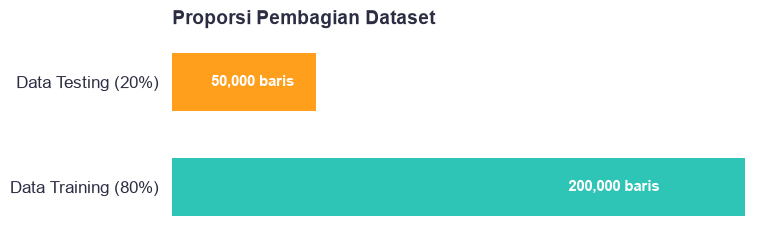

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Membagi Data Training (80%) dan Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data untuk visualisasi
labels = ['Data Training (80%)', 'Data Testing (20%)']
sizes = [X_train.shape[0], X_test.shape[0]]
colors = ['#2ec4b6', '#ff9f1c']  # Warna tema modern (Toska & Oranye)

# Set style diagram
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 2.5))

# Membuat bar horizontal
bars = ax.barh(labels, sizes, color=colors, height=0.55, edgecolor='none')

# Menghilangkan border box diagram agar minimalis
sns.despine(left=True, bottom=True)

# Menambahkan teks jumlah baris di dalam/ujung bar secara otomatis
for bar in bars:
    width = bar.get_width()
    ax.text(width - (width * 0.15),  # Posisi teks sedikit masuk ke dalam bar
            bar.get_y() + bar.get_height()/2,
            f'{width:,} baris',
            va='center', ha='right', 
            color='white', fontweight='bold', fontsize=11)

# Mengatur judul dan estetika
ax.set_title("Proporsi Pembagian Dataset", fontsize=14, fontweight='bold', pad=15, loc='left', color='#2b2d42')
ax.xaxis.set_visible(False)  # Sembunyikan angka koordinat X bawah agar bersih
ax.tick_params(axis='y', labelsize=12, colors='#2b2d42')
ax.grid(False)  # Matikan gridline

plt.tight_layout()
plt.show()

In [17]:
# 5. Membangun dan Melatih Model Random Forest
print("⏳ 2. Melatih AI (Random Forest) sedang berjalan...")
# Menggunakan n_jobs=-1 agar Python menggunakan seluruh inti CPU laptop Anda
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("   -> Pelatihan selesai!\n")

⏳ 2. Melatih AI (Random Forest) sedang berjalan...
   -> Pelatihan selesai!



In [18]:


# 6. Evaluasi dan Cetak Rapor AI
print("⏳ 3. Mengevaluasi performa prediksi model...")
y_pred = rf_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

# Membuat laporan menjadi format tabel pandas
report_dict = classification_report(y_test, y_pred, target_names=['Sehat (0)', 'Sakit (1)'], output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

# Styling agar tampilannya cantik di Jupyter Notebook
styled_report = df_report.style.background_gradient(cmap='Greens', subset=['precision', 'recall', 'f1-score']) \
    .format("{:.2f}") \
    .set_caption(f"🎯 AKURASI KESELURUHAN MODEL: {akurasi * 100:.2f}%")

print("\n📊 CLASSIFICATION REPORT:")
display(styled_report)

⏳ 3. Mengevaluasi performa prediksi model...

📊 CLASSIFICATION REPORT:


,precision,recall,f1-score,support
Sehat (0),0.55,0.68,0.61,27443.00
Sakit (1),0.45,0.31,0.37,22557.00
accuracy,0.52,0.52,0.52,0.52
macro avg,0.50,0.50,0.49,50000.00
weighted avg,0.50,0.52,0.50,50000.00


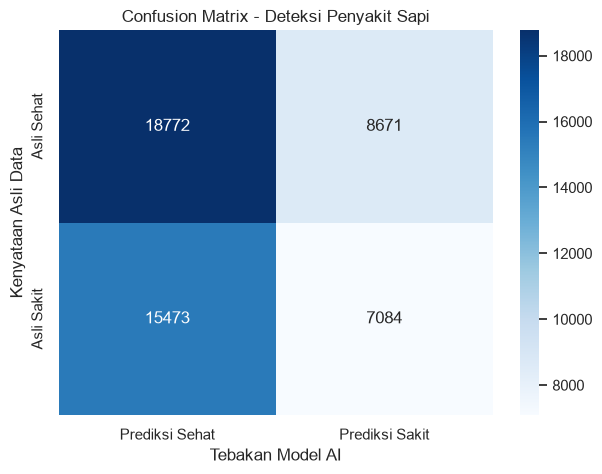

In [19]:
# 7. Visualisasi Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi Sehat', 'Prediksi Sakit'],
            yticklabels=['Asli Sehat', 'Asli Sakit'])
plt.title('Confusion Matrix - Deteksi Penyakit Sapi')
plt.xlabel('Tebakan Model AI')
plt.ylabel('Kenyataan Asli Data')
plt.show()